In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

In [2]:
_path1 = 'C:\\Users\\86994\\Desktop\\11.jpg'
image = cv2.imread(_path1)
print(image.shape)

(811, 496, 3)


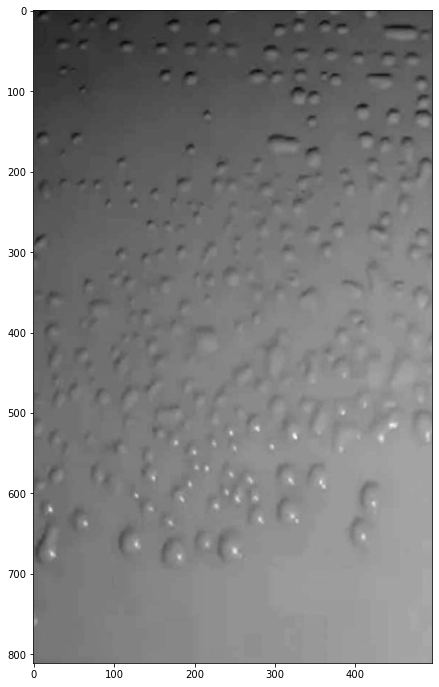

In [3]:
img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(9,12))
plt.imshow(img_gray, cmap='gray')

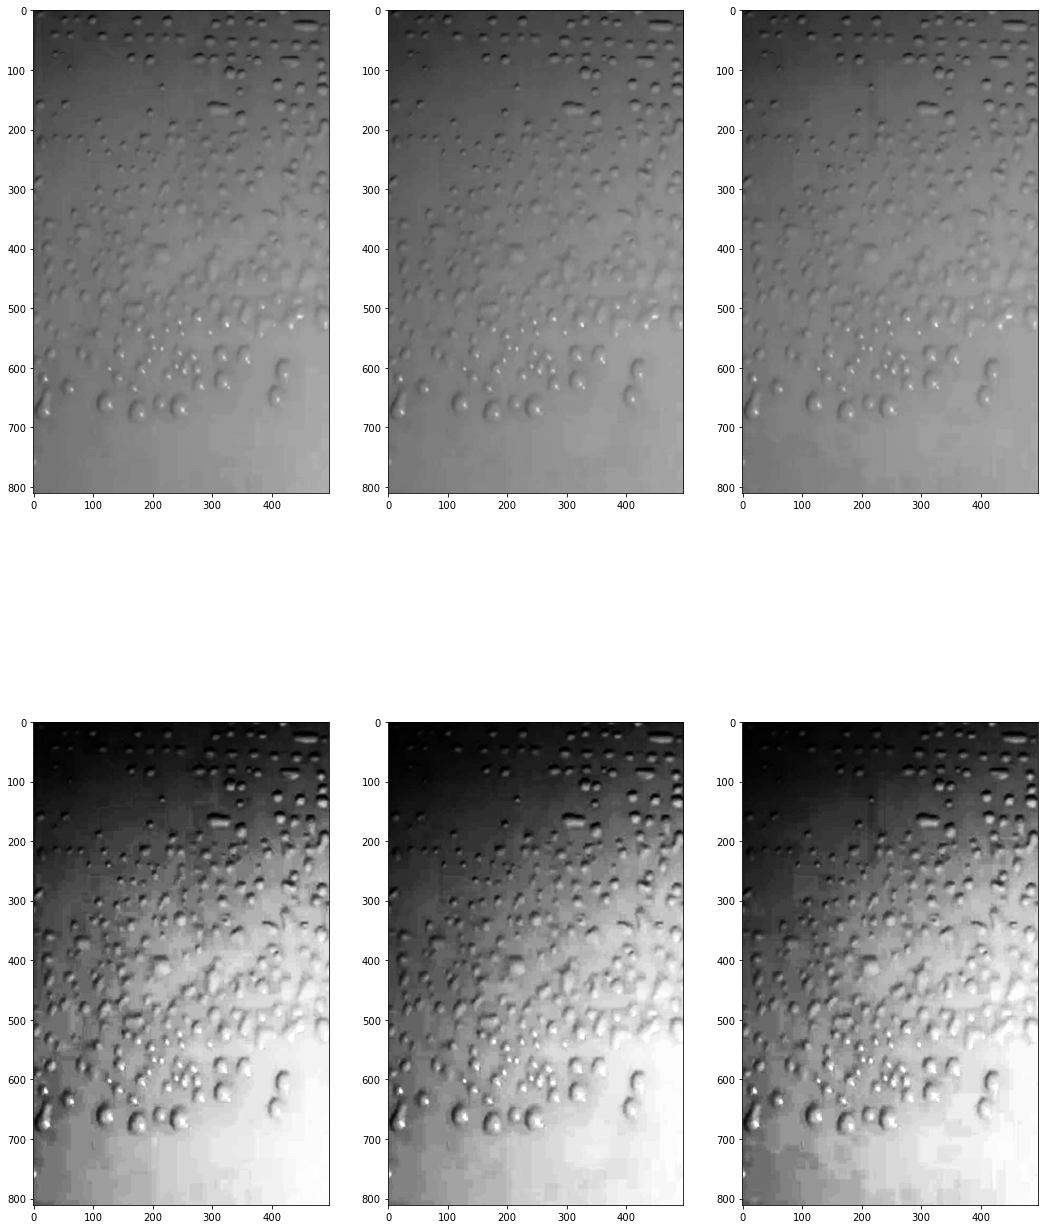

In [4]:
plt.figure(figsize=(18,24))
for i in [1,2,3]: # BGR通道作图
    plt.subplot(2,3,i)
    plt.imshow(image[:,:,i-1], cmap='gray') 
    
for i in [4,5,6]: # BGR通道作图,直方图均衡化之后
    plt.subplot(2,3,i)
    plt.imshow(cv2.equalizeHist(image[:,:,i-4]), cmap='gray') 
plt.show()

In [5]:
img_eHists = [cv2.equalizeHist(image[:,:,i]) for i in [0,1,2]] # 直方图均衡化后列表

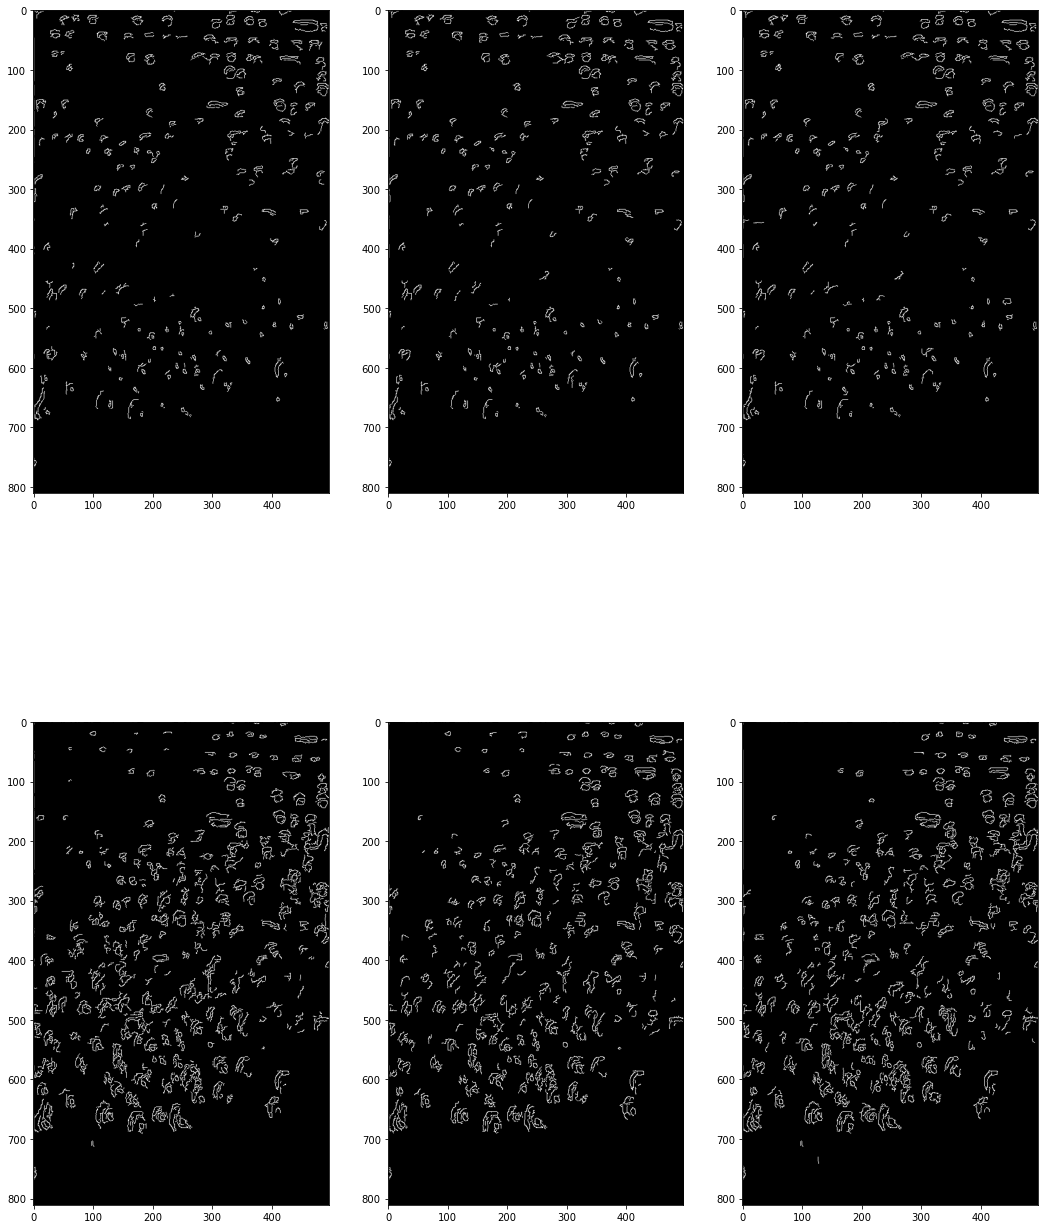

In [6]:
plt.figure(figsize=(18,24))
for i in [1,2,3]: # BGR通道作图
    plt.subplot(2,3,i)
    plt.imshow(cv2.Canny(image[:,:,i-1], 20,50), cmap='gray') 
for i in [4,5,6]: # BGR通道作图
    plt.subplot(2,3,i)
    plt.imshow(cv2.Canny(img_eHists[i-4], 80,150), cmap='gray') 

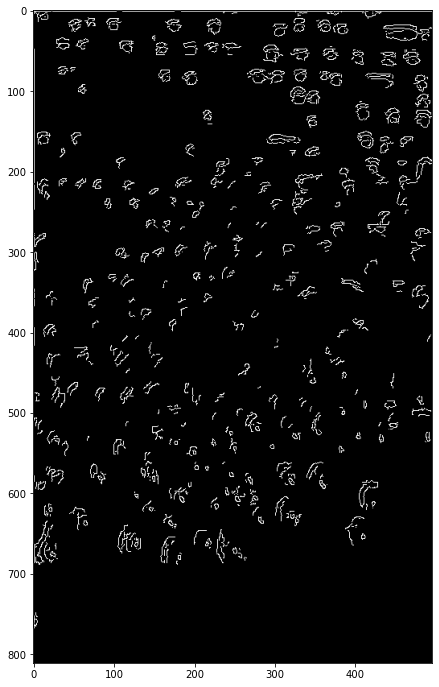

In [7]:
_canny_gray = cv2.Canny(img_gray, 20,35)
plt.figure(figsize=(9,12))
plt.imshow(_canny_gray, cmap='gray')

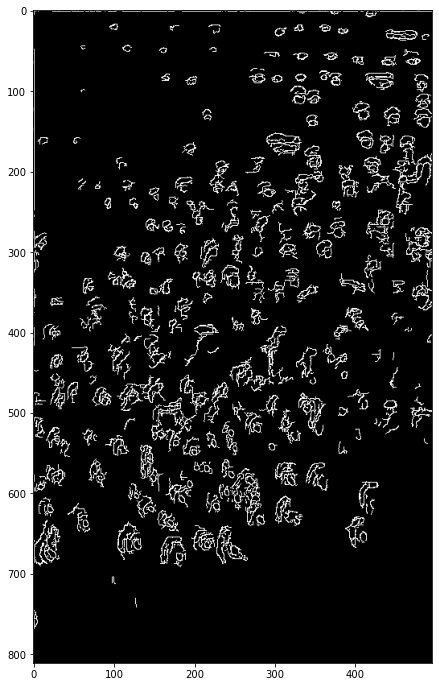

In [8]:
_canny_imgs = [cv2.Canny(img_eHists[i], 80,150) for i in [0,1,2]]
canny_imgs_add = _canny_imgs[0]+_canny_imgs[1]+_canny_imgs[2]
plt.figure(figsize=(9,12))
plt.imshow(canny_imgs_add, cmap='gray')

In [9]:
#找轮廓并发现最大轮廓
contours, hierarchy	= cv2.findContours(canny_imgs_add, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

contours_size = np.array([cv2.arcLength(s,closed=True) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓，按t增加索引

In [ ]:
# 去掉非闭合轮廓


In [10]:
contours_hull = [cv2.convexHull(cont) for cont in contours]

In [11]:
# 求面积
contours_area = [cv2.contourArea(contour) for contour in contours_hull]
contours_area = np.array(contours_area)

In [15]:
print(np.count_nonzero(contours_area<=10))
_filter_index = [_i for _i in range(0, len(contours))]
_filter_index = np.array(_filter_index)
_filter_index = _filter_index[contours_area>=10]
filter_index = _filter_index

105


In [16]:
_all_areas = np.sum(contours_area)
print(_all_areas)
print(_all_areas/(image.shape[0]*image.shape[1]))

263514.5
0.655091533749652


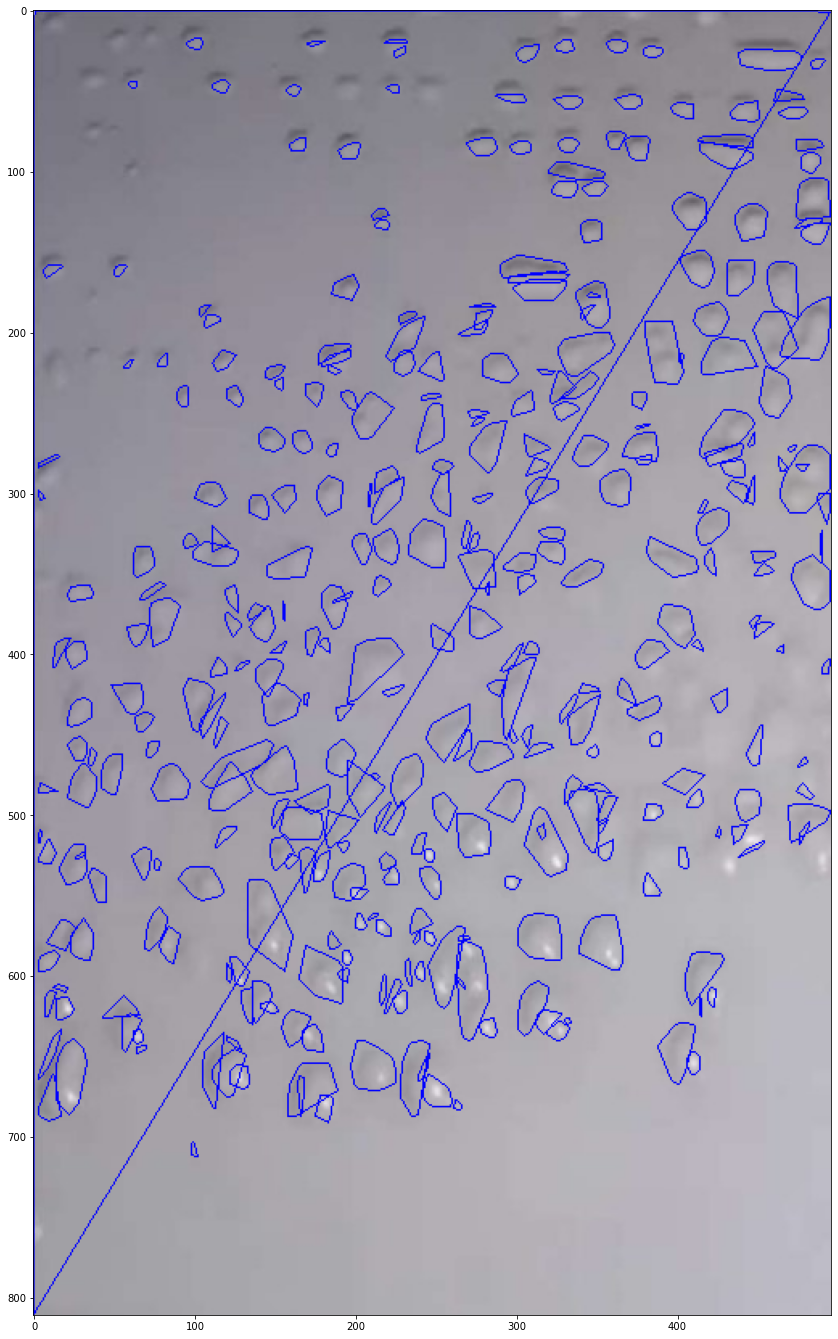

In [17]:
plt.figure(figsize=(18,24))
src_img = image.copy()
for _i in filter_index:
    cv2.drawContours(src_img, contours_hull, _i, (255,0,0), thickness=1) #画原轮廓，绿色
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
src_img = image.copy()
for _i in range(0, len(contours)):
    cv2.drawContours(src_img, contours, _i, (0,255,0), thickness=1) #画原轮廓，绿色
plt.figure(figsize=(18,24))
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.show()